# Financial Precarity Simulation


## Reproduction of Nokhiz et al. (2024)


### Assets, Precarity, Interventions, Gig vs Office Worker


Chay tu tren xuong duoi. Moi cell la mot phan cua mo phong.


### Setup 1: Imports and Configuration


In [1]:
''' Installing some prerequisites'''    
%pip install interpolation
epsilon_0 = 0.1

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy import interpolate as intrp
from scipy.stats import entropy
from interpolation import interp
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['figure.facecolor'] = 'white'
matplotlib.rcParams['figure.figsize'] = (20, 10)
matplotlib.rcParams['legend.fontsize'] = 25
matplotlib.rcParams['axes.labelsize'] = 32
matplotlib.rcParams['axes.titlesize'] = 32
matplotlib.rcParams['xtick.labelsize'] = 32
matplotlib.rcParams['ytick.labelsize'] = 32

np.random.seed(29)



### Setup 2: DATA SETUP (giống notebook gốc)


In [3]:

inc_perc_2019 = np.array([0, 610.12, 4067.48, 7118.1, 9151.84, 10168.71,
    11185.58, 12308.21, 13592.52, 14849.37, 15912, 17143.43, 18303.68,
    19341.91, 20337.42, 21386.83, 22585.73, 24021.55, 25197.05, 25986.14,
    27292.82, 28472.39, 29710.94, 30510.2, 31727.4, 32844.94, 34237.04,
    35590.49, 36511.78, 37624.23, 38702.12, 40381.99, 41062.27, 42664.86,
    43766.13, 45351.44, 46320.52, 47792.94, 49114.88, 50843.56, 51120.15,
    52674.94, 53953.15, 55816.06, 56944.79, 58404, 59995.4, 61027.52,
    62557.91, 64093.39, 65953.25, 67225.35, 69039.45, 70736.61, 71992.44,
    73744.51, 75899.26, 77109.34, 78874.63, 80867.7, 82366.56, 84420.64,
    86474.72, 88471.86, 90961.16, 92536.29, 94841.54, 97184.41, 99805.9,
    101891.51, 104403.18, 106873.16, 109407.2, 112059.2, 114916.61,
    118074, 121705.24, 124363.34, 128125.77, 132193.25, 135856.02,
    140328.22, 144539.08, 149581.75, 153673.64, 159080.34, 165244.62,
    171851.23, 178813.74, 187307.67, 197314.7, 207041.07, 219817.04,
    235075.19, 252493.18, 276588.96, 310655.16, 365232.67, 483131.76])

prctng = np.array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1,
    0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22,
    0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.31, 0.32, 0.33, 0.34,
    0.35, 0.36, 0.37, 0.38, 0.39, 0.4, 0.41, 0.42, 0.43, 0.44, 0.45, 0.46,
    0.47, 0.48, 0.49, 0.5, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58,
    0.59, 0.6, 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69, 0.70,
    0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8, 0.81, 0.82,
    0.83, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.9, 0.91, 0.92, 0.93, 0.94,
    0.95, 0.96, 0.97, 0.98, 0.99])

interp_ = intrp.interp1d(prctng, inc_perc_2019, fill_value="extrapolate")
values_ = interp_(np.random.random(size=10000))
incomes = values_ / 12000.0

inc_10 = np.percentile(incomes, 10)
inc_20 = np.percentile(incomes, 20)
inc_30 = np.percentile(incomes, 30)
inc_40 = np.percentile(incomes, 40)
inc_50 = np.percentile(incomes, 50)
inc_60 = np.percentile(incomes, 60)
inc_70 = np.percentile(incomes, 70)
inc_80 = np.percentile(incomes, 80)
inc_90 = np.percentile(incomes, 90)
inc_99 = np.percentile(incomes, 99)

# Income averages by decile
def compute_avg(inc, lo, hi):
    return np.mean([k for k in inc if (lo is None or k >= lo) and (hi is None or k < hi)])

inc_10_avg = compute_avg(incomes, None, inc_10)
inc_20_avg = compute_avg(incomes, inc_10, inc_20)
inc_30_avg = compute_avg(incomes, inc_20, inc_30)
inc_40_avg = compute_avg(incomes, inc_30, inc_40)
inc_50_avg = compute_avg(incomes, inc_40, inc_50)
inc_60_avg = compute_avg(incomes, inc_50, inc_60)
inc_70_avg = compute_avg(incomes, inc_60, inc_70)
inc_80_avg = compute_avg(incomes, inc_70, inc_80)
inc_90_avg = compute_avg(incomes, inc_80, inc_90)
inc_99_avg = compute_avg(incomes, inc_90, inc_99)
inc_99_avg_more = compute_avg(incomes, inc_99, None)

Incomes = (inc_10_avg, inc_20_avg, inc_30_avg, inc_40_avg, inc_50_avg,
           inc_60_avg, inc_70_avg, inc_80_avg, inc_90_avg, inc_99_avg, inc_99_avg_more)

stateseq = list(range(11))

# Savings data
saving_val = np.array([-94516.52, -54867.26, -35734.82,
    -25936.24, -18386.58, -11926.06, -7469.49, -3835.64, -1832.38, -466.58,
    3.43, 178.2, 502.44, 860.92, 1577.19, 2592.8, 3452.04, 4480.43, 5378.37,
    6368.35, 7363.47, 8511.79, 9689.16, 10777.34, 12430.11, 14197.79,
    16060.99, 18106.62, 20340.88, 23695.62, 27250.07, 30994.35, 36382.96,
    40616.62, 45081.82, 50409.19, 55408.58, 59543.95, 63103.9, 67469.07,
    71802.48, 75801.39, 80406.68, 84408.2, 89548.35, 94983.2, 100589.66,
    106335.51, 114194.83, 121411.37, 127446.43, 134207.73, 141621.65,
    150028.88, 158430.46, 167469.68, 174943.76, 182100.06, 191929.7,
    201311.36, 211096.7, 219405.74, 228563.2, 238313.46, 249137.43,
    260147.01, 271875.08, 288498.14, 301999.85, 314920.61, 328617.37,
    349362.49, 365919.18, 382911.64, 403283.56, 428623.03, 455610.73,
    485176.88, 523925.5, 558189.68, 591350.95, 637050.12, 681782.41,
    737122.98, 795218.85, 854908.75, 928665.81, 991188.75, 1085969.92,
    1219126.46, 1355268.26, 1541905.98, 1767510.16, 2080569.86, 2584130.26,
    3294388.49, 4640603.15, 6557022.79, 11099166.07])

savings_prctng = np.arange(0.01, 1.0, 0.01)
interp_s = intrp.interp1d(savings_prctng, saving_val, fill_value="extrapolate")
savings_s = interp_s(np.random.random(size=10000)) / 1000

savings_10 = np.percentile(savings_s, 10)
savings_20 = np.percentile(savings_s, 20)
savings_30 = np.percentile(savings_s, 30)
savings_40 = np.percentile(savings_s, 40)
savings_50 = np.percentile(savings_s, 50)
savings_60 = np.percentile(savings_s, 60)
savings_70 = np.percentile(savings_s, 70)
savings_80 = np.percentile(savings_s, 80)
savings_90 = np.percentile(savings_s, 90)
savings_99 = np.percentile(savings_s, 99)

Savings = [savings_10, savings_20, savings_30, savings_40, savings_50,
           savings_60, savings_70, savings_80, savings_90, savings_99]




### Setup 3: Helper Functions + Classifier + Agent Simulation + Find Agents


In [4]:

def basic_expenditure(income):
    """Chi tiêu cơ bản hàng tháng dựa trên income bracket."""
    if income <= inc_10:
        return 25856 / 12 / 1000
    if income <= inc_20:
        return 31499 / 12 / 1000
    if income <= inc_30:
        return 37131 / 12 / 1000
    if income <= inc_40:
        return 43822 / 12 / 1000
    if income <= inc_50:
        return 49367 / 12 / 1000
    if income <= inc_60:
        return 56720 / 12 / 1000
    if income <= inc_70:
        return 66435 / 12 / 1000
    if income <= inc_80:
        return 75945 / 12 / 1000
    if income <= inc_90:
        return 96913 / 12 / 1000
    return 145967 / 12 / 1000


def getIncomeState(income):
    """Trả về income state (0..10)."""
    if income < inc_10:
        return 0
    if income < inc_20:
        return 1
    if income < inc_30:
        return 2
    if income < inc_40:
        return 3
    if income < inc_50:
        return 4
    if income < inc_60:
        return 5
    if income < inc_70:
        return 6
    if income < inc_80:
        return 7
    if income < inc_90:
        return 8
    if income < inc_99:
        return 9
    return 10


def getIncomeClass(income):
    return getIncomeState(income)


def getState(indiv_savings_status):
    """Trả về savings state list."""
    s_class = []
    for x in indiv_savings_status:
        if x < savings_10:
            s_class.append(0)
        elif x < savings_20:
            s_class.append(1)
        elif x < savings_30:
            s_class.append(2)
        elif x < savings_40:
            s_class.append(3)
        elif x < savings_50:
            s_class.append(4)
        elif x < savings_60:
            s_class.append(5)
        elif x < savings_70:
            s_class.append(6)
        elif x < savings_80:
            s_class.append(7)
        elif x < savings_90:
            s_class.append(8)
        elif x < savings_99:
            s_class.append(9)
        else:
            s_class.append(10)
    return s_class


def get_savings(income):
    """Savings dựa trên income bracket."""
    if income < np.percentile(incomes, 20):
        return 9.30
    if income < np.percentile(incomes, 40):
        return 43.80
    if income < np.percentile(incomes, 60):
        return 95.62
    if income < np.percentile(incomes, 80):
        return 205.20
    if income < np.percentile(incomes, 90):
        return 387.85
    return 1589.30


# ── EGM CONSUMPTION MODEL ─────────────────────────────────────

class ConsumptionModel:
    """Mô hình tiêu dùng CRRA, giải bằng EGM (không dùng jitclass)."""
    def __init__(self, γ=1.5, β=0.90, Rt=1.10, P=-10.0, grid_max=500, grid_size=10000, seed=1234):
        np.random.seed(seed)
        self.γ = γ
        self.β = β
        self.P = P
        self.Rt = Rt
        self.s_grid = np.linspace(0, grid_max, grid_size)
        assert β * Rt < 1, "Stability condition failed."

    def R(self):
        return self.Rt

    def get_incomes(self):
        return np.array(Incomes)

    def generate_polynomial(self, y, x):
        n = int(np.ceil((self.γ * (self.Rt - 1)) / (self.Rt - 1 - (self.β / 2))))
        p = [0.0 for _ in range(n + 1)]
        c = ((self.γ / (1 - self.γ)) * (1 / (self.β * self.P))) ** (1 / (self.γ - 1))
        p[-2] = (self.γ * self.Rt) / ((self.γ - 1) * (self.Rt - 1) + (self.β / 2))
        p[-1] = -(x + y / self.Rt)
        return p

    def generate_polynomial_neg(self, y, x, tol=1e-15):
        n = 1 + round((self.γ * (self.Rt - 1)) / (1 + (self.β / 2) - self.Rt) + tol)
        p = [0.0 for _ in range(n + 1)]
        c = ((self.γ / (1 - self.γ)) * (1 / (self.β * self.P))) ** (1 / (self.γ - 1))
        k = -1 * ((self.γ * (self.Rt - 1)) / (self.β / 2 + (self.γ - 1) * (self.Rt - 1))) * \
            (c ** (1 - ((self.γ * self.Rt) / (self.Rt - 1 - self.β / 2))))
        p[-1] = k
        p[0] = (self.γ * self.Rt) / ((self.γ - 1) * (self.Rt - 1) + (self.β / 2))
        p[1] = -(x + y / self.Rt)
        return p


def get_consumption(y, x, p, tol=1e-15, min_con=True):
    """Tìm consumption từ nghiệm của đa thức."""
    min_c = basic_expenditure(y) if min_con else 0
    roots = np.roots(p)
    real_valued = roots.real[abs(roots.imag) < tol]
    admissible = real_valued[real_valued >= 0]
    if admissible.size == 0:
        return min_c
    return max(np.real(np.amax(admissible)), min_c)


def K(a_in, σ_in, con_model):
    """Một bước lặp của Endogenous Grid Method."""
    s_grid = con_model.s_grid
    n = con_model.get_incomes().size
    generate_polynomial_neg = con_model.generate_polynomial_neg
    σ_out = np.empty_like(σ_in)

    for i, s in enumerate(s_grid):
        for y in range(n):
            Y_hat = con_model.get_incomes()[y]
            C = get_consumption(Y_hat, s, generate_polynomial_neg(Y_hat, s))
            σ_out[i, y] = C

    a_out = np.empty_like(σ_out)
    for z in range(n):
        a_out[:, z] = s_grid + σ_out[:, z]

    σ_out[0, :] = 0
    a_out[0, :] = 0
    return a_out, σ_out


def solve_model_time_iter(model, a_vec, σ_vec):
    return K(a_vec, σ_vec, model)


# ── BUILD CONSUMPTION POLICY ───────────────────────────────────
print("Building consumption policy (EGM)...")
con_model = ConsumptionModel()
k = len(con_model.s_grid)
n = con_model.get_incomes().size
σ_init = np.empty((k, n))
for z in range(n):
    σ_init[:, z] = con_model.s_grid
a_init = np.copy(σ_init)

a_star, σ_star = solve_model_time_iter(con_model, a_init, σ_init)
print("EGM solution complete.")


# ── PRECARITY QUANTIFICATION ──────────────────────────────────

def getEntropy(sequence):
    value, counts = np.unique(sequence, return_counts=True)
    return entropy(counts, base=2)


def generateWeight(sequence, values, states):
    weights = []
    for i in range(1, len(sequence)):
        m = states.index(sequence[i])
        n = states.index(sequence[i - 1])
        weights.append(np.exp((1e-22) * abs(values[m] - values[n])))
    return weights


def complexity(sequence, stateSpace):
    na = len(stateSpace)
    ls = len(sequence)
    currentState = sequence[0]
    nts = 0
    for i in range(len(sequence)):
        if sequence[i] != currentState:
            nts += 1
            currentState = sequence[i]
    if ls <= 1 or na <= 1:
        return 0
    return np.sqrt((getEntropy(sequence) / np.log2(na)) * (nts / (ls - 1)))


def getWellBeing(income):
    if income <= 25000 / 12000:
        return 1 / 0.55
    if income <= 50000 / 12000:
        return 1 / 0.67
    if income <= 100000 / 12000:
        return 1 / 0.85
    return 1 / 0.96


def precarityQuantification(sequence, stateSpace, weights, lambdav, alpha, beta,
                            init_state, windowSize=-1, useInit=False, useIncome=False, income=0):
    n = len(sequence)
    st = 0
    if windowSize != -1:
        st = n - windowSize
    if st < 0:
        st = 0
    if st == 0 and useInit:
        startState = init_state
    else:
        startState = sequence[st]

    currentState = sequence[st]
    negativeWts = 0
    positiveWts = 0
    for i in range(st + 1, len(sequence)):
        if sequence[i] >= currentState:
            positiveWts += weights[i - 1]
        else:
            negativeWts += weights[i - 1]
        currentState = sequence[i]

    totalWts = sum(weights[st:])
    if totalWts != 0:
        Qs = negativeWts / totalWts - positiveWts / totalWts
    else:
        Qs = 0

    if useIncome:
        init_cost = (1 + len(stateSpace) - startState) * getWellBeing(income)
    else:
        init_cost = (1 + len(stateSpace) - startState)

    return lambdav * init_cost + (1 - lambdav) * \
        (complexity(sequence, stateSpace) ** alpha) * ((1 + Qs) ** beta)


def get_sequence(a, assets_lvls, asset_states):
    """Chuyển mảng tài sản thành sequence các state (giống file gốc)."""
    sequence = []
    n = len(assets_lvls)
    for a_ in a:
        found = False
        for i in range(n):
            if a_ <= assets_lvls[i]:
                sequence.append(i)
                found = True
                break
        if not found:
            sequence.append(n - 1)  # gán vào state cao nhất
    return sequence



from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.model_selection import cross_val_score, KFold

np.random.seed(29)


def getLabel(income):
    if income <= 25000 / 12000:
        return 0
    elif income <= 50000 / 12000:
        from scipy.stats import bernoulli
        return bernoulli.rvs(0.67 - 0.25)
    elif income <= 100000 / 12000:
        from scipy.stats import bernoulli
        return bernoulli.rvs(0.85 - 0.25)
    else:
        return 1


def generateData(incomes_arr, sample_size):
    income_sample = np.random.choice(incomes_arr, sample_size, False)
    savings_sample = np.array([get_savings(inc) for inc in income_sample])
    label_sample = np.array([getLabel(inc) for inc in income_sample])
    features = np.array([savings_sample, income_sample]).T
    return features, label_sample.T


def getClassifier(features, labels):
    clf = GradientBoostingClassifier()
    clf.fit(features, labels)
    return clf


# Train classifier
features, labels = generateData(incomes, 10000)
clf_real = getClassifier(features, labels)



T = 60


def compute_asset_series_static_clf(con_model, a_star, σ_star, z_init, clf,
                                    initincome=0, T=500_000, init_a=0,
                                    permanenet_shock_gap=500_000,
                                    temporary_shock_gap=500_000,
                                    permanenet_shock=0, temporary_shock=0):
    σ_func = lambda a, z: interp(a_star[:, z], σ_star[:, z], a)
    a = np.zeros(T + 1)
    a[0] = init_a
    y_val = [initincome]
    current_income = initincome
    for t in range(T):
        label = clf.predict(np.array([[a[t], current_income]]))[0]
        if ((t + 1) % permanenet_shock_gap == 0) and label == 0:
            current_income *= (1 - permanenet_shock)
        elif ((t + 1) % permanenet_shock_gap == 0) and label == 1:
            current_income *= (1 + permanenet_shock)

        y_tmp = current_income
        if ((t + 1) % temporary_shock_gap == 0) and label == 0:
            current_income *= (1 - temporary_shock)
        elif ((t + 1) % temporary_shock_gap == 0) and label == 1:
            current_income *= (1 + temporary_shock)

        R = con_model.R()
        z = getIncomeState(current_income)
        s = a[t] - max(σ_func(a[t], z), basic_expenditure(y_tmp))
        a[t + 1] = R * s + current_income
        y_val.append(current_income)

        if ((t + 1) % temporary_shock_gap == 0):
            current_income = y_tmp
        if a[t + 1] <= 0:
            break
    return a, y_val


def compute_asset_series_static_clf_interventions(con_model, a_star, σ_star,
                                                  z_init, clf, initincome=0,
                                                  T=500, init_a=0,
                                                  permanenet_shock_gap=500,
                                                  temporary_shock_gap=500,
                                                  permanenet_shock=0,
                                                  temporary_shock=0,
                                                  interventions=None):
    if interventions is None:
        interventions = {}
    one_shot_interventions = {}
    temporal_interventions = {}
    for key in interventions:
        if interventions[key]['type'] == 'one_shot':
            one_shot_interventions[key] = interventions[key]['value']
        else:
            dur = interventions[key]['duration']
            for i in range(dur):
                temporal_interventions[key + i] = interventions[key]['rate_function']

    σ_func = lambda a, z: interp(a_star[:, z], σ_star[:, z], a)
    a = np.zeros(T + 1)
    a[0] = init_a
    y_val = [initincome]
    current_income = initincome
    for t in range(T):
        label = clf.predict(np.array([[a[t], current_income]]))[0]

        if ((t + 1) % permanenet_shock_gap == 0) and label == 0:
            current_income *= (1 - permanenet_shock)
        elif ((t + 1) % permanenet_shock_gap == 0) and label == 1:
            current_income *= (1 + permanenet_shock)

        y_tmp = current_income
        if ((t + 1) % temporary_shock_gap == 0) and label == 0:
            current_income *= (1 - temporary_shock)
        elif ((t + 1) % temporary_shock_gap == 0) and label == 1:
            current_income *= (1 + temporary_shock)

        if (t + 1) in one_shot_interventions:
            current_income += one_shot_interventions[t + 1]
        if (t + 1) in temporal_interventions:
            current_income *= temporal_interventions[t + 1](current_income)

        R = con_model.R()
        z = getIncomeState(current_income)
        s = a[t] - max(σ_func(a[t], z), basic_expenditure(y_tmp))
        a[t + 1] = R * s + current_income
        y_val.append(current_income)

        if ((t + 1) % temporary_shock_gap == 0):
            current_income = y_tmp
        current_income = y_tmp
        if a[t + 1] <= 0:
            break
    return a, y_val



np.random.seed(29)
features_small, labels_small = generateData(incomes, 100)
predictions = clf_real.predict(features_small)

predictions_0 = [features_small[i] for i in range(len(predictions)) if predictions[i] == 0]
predictions_1 = [features_small[i] for i in range(len(predictions)) if predictions[i] == 1]

best_pair = None
best_dissimilarity = float('inf')
for p0 in predictions_0:
    for p1 in predictions_1:
        dissim = pairwise_distances([np.array(p0)], [np.array(p1)], metric="l2")[0][0]
        if dissim < best_dissimilarity:
            best_pair = (np.array(p0), np.array(p1))
            best_dissimilarity = dissim

print(f"Best pair found: dissimilarity = {best_dissimilarity:.4f}")
print(f"Agent 1 (label 1): savings={best_pair[1][0]:.2f}, income={best_pair[1][1]:.4f}")
print(f"Agent 2 (label 0): savings={best_pair[0][0]:.2f}, income={best_pair[0][1]:.4f}")




Building consumption policy (EGM)...
EGM solution complete.
Best pair found: dissimilarity = 0.0156
Agent 1 (label 1): savings=43.80, income=3.9171
Agent 2 (label 0): savings=43.80, income=3.9327


## Graph 1: GRAPH 1: MINOR INCOME DIFFERENCE — ASSETS + PRECARITY



--- Graph 1: Minor Income Difference ---


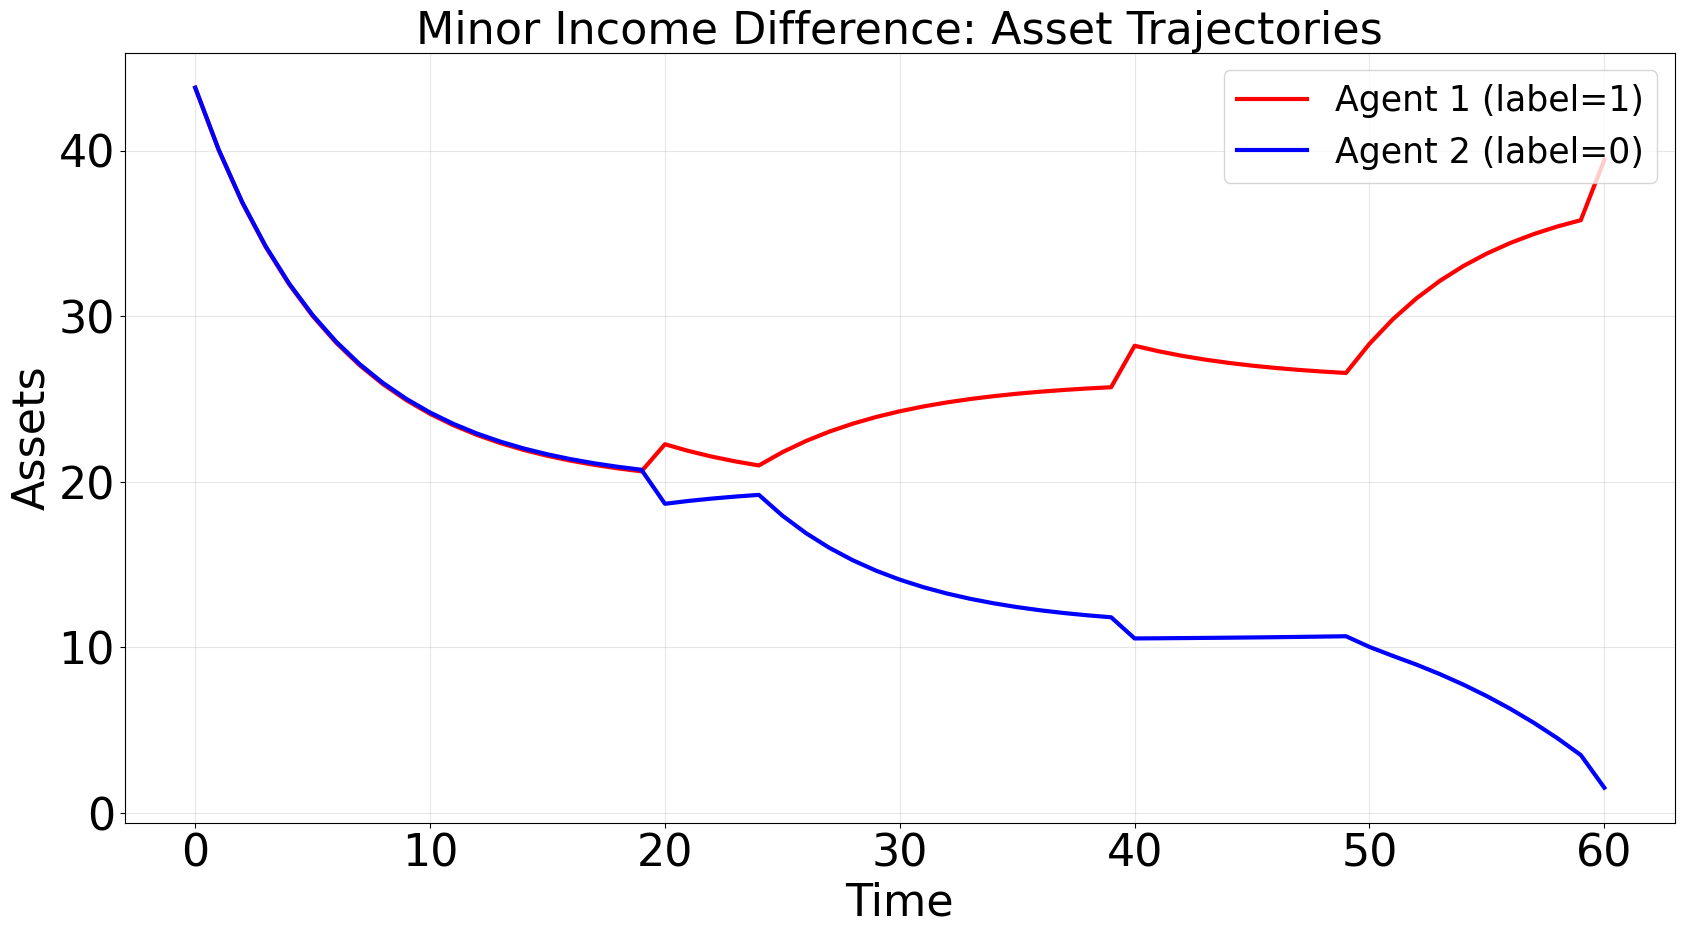

Window size: 10


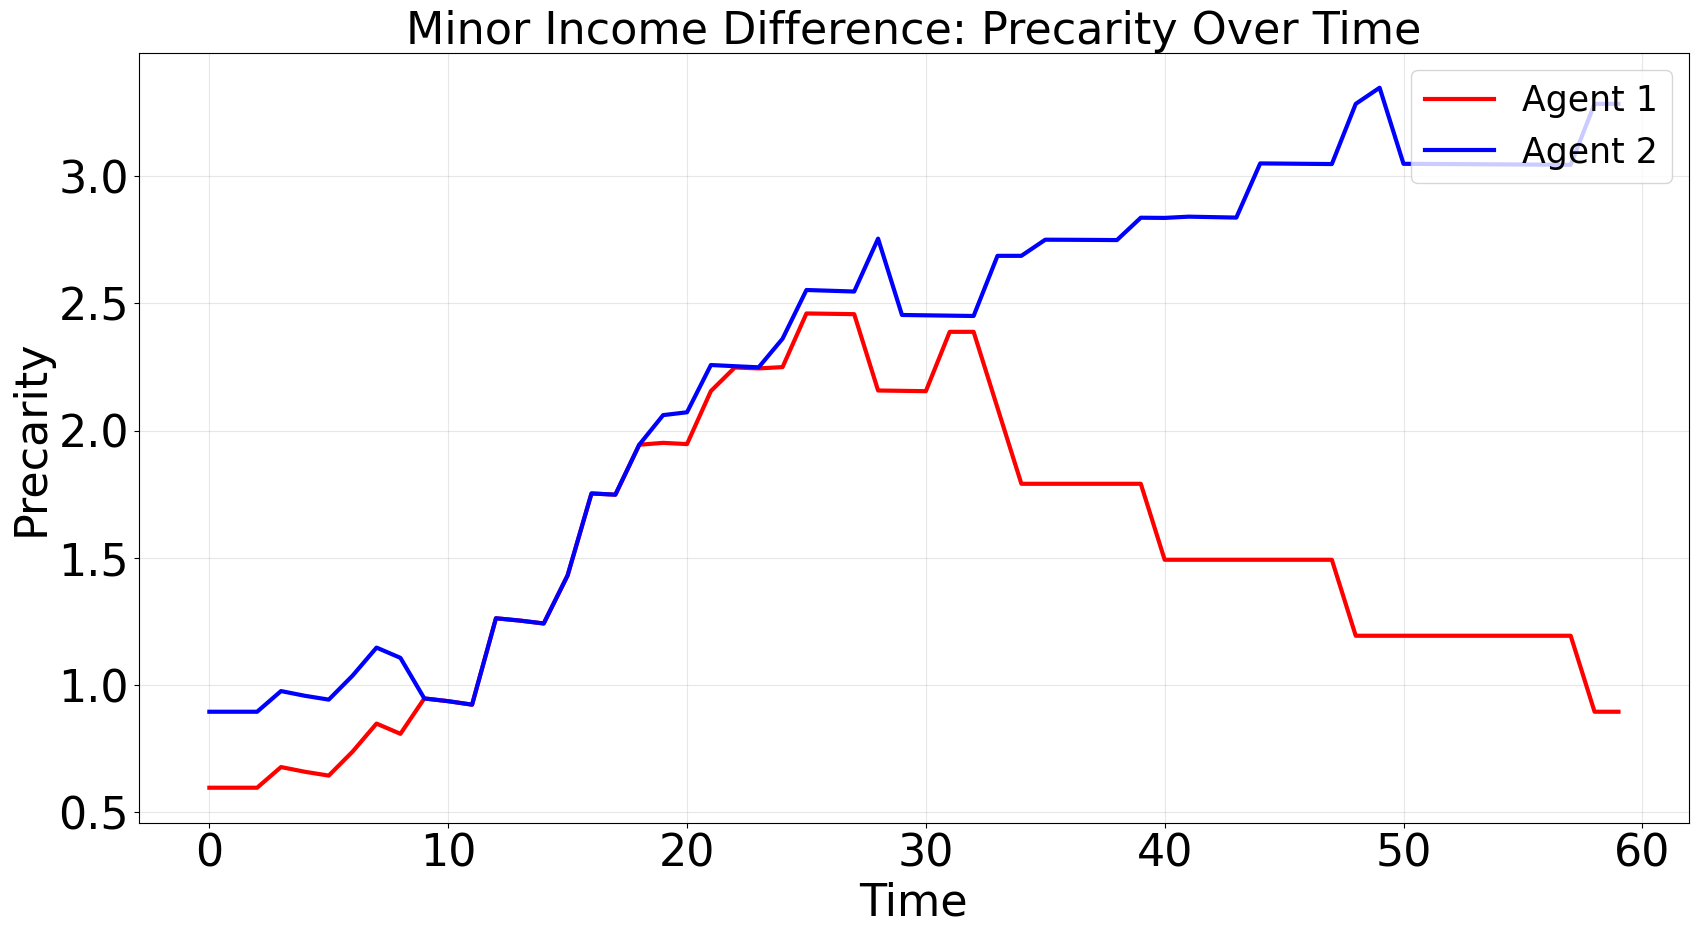

In [5]:
print("\n--- Graph 1: Minor Income Difference ---")

init_income = best_pair[1][1]
init_saving = best_pair[1][0]
init_state_1 = getState([init_saving])[0]
a_1, inc_1 = compute_asset_series_static_clf(
    con_model, a_star, σ_star, init_state_1, clf_real,
    initincome=init_income, T=T, init_a=init_saving,
    permanenet_shock_gap=25, temporary_shock_gap=20,
    permanenet_shock=0.4, temporary_shock=0.6)
init_saving_1 = init_saving
init_income1 = init_income

init_income = best_pair[0][1]
init_saving = best_pair[0][0]
init_state_2 = getState([init_saving])[0]
a_2, inc_2 = compute_asset_series_static_clf(
    con_model, a_star, σ_star, init_state_2, clf_real,
    initincome=init_income, T=T, init_a=init_saving,
    permanenet_shock_gap=25, temporary_shock_gap=20,
    permanenet_shock=0.4, temporary_shock=0.6)
init_saving_2 = init_saving

# Assets plot
plt.figure(1, figsize=(20, 10))
plt.plot(range(len(a_1)), a_1, label="Agent 1 (label=1)", linewidth=3, color='red')
plt.plot(range(len(a_2)), a_2, label="Agent 2 (label=0)", linewidth=3, color='blue')
plt.legend(loc="upper right")
plt.ylabel('Assets')
plt.xlabel('Time')
plt.title('Minor Income Difference: Asset Trajectories')
plt.grid(alpha=0.3)
plt.savefig('g1_minor_diff_assets.png', dpi=100, bbox_inches='tight')
plt.show()

# Precarity computation
a_mean = np.array(list(a_1) + list(a_2))
a_unique = np.unique(a_mean)
assets_lvls = [np.percentile(a_unique, 10 * (i + 1)) for i in range(10)]
asset_states = list(range(10))

delta = 1
init_prec_state_1 = min(np.array(get_sequence(np.array([init_saving_1]), assets_lvls, asset_states))[0] + delta, asset_states[-1])
init_prec_state_2 = max(np.array(get_sequence(np.array([init_saving_2]), assets_lvls, asset_states))[0] - delta, asset_states[0])

ws = 10
print(f"Window size: {ws}")

a_1_seq = get_sequence(a_1, assets_lvls, asset_states)
a_2_seq = get_sequence(a_2, assets_lvls, asset_states)

precarity_1 = []
for i in range(1, len(a_1)):
    w = generateWeight(a_1_seq[:i + 1], values=assets_lvls, states=asset_states)
    precarity_1.append(precarityQuantification(
        a_1_seq[:i + 1], asset_states, w, 0.2, 1, 1.2,
        init_prec_state_1, windowSize=ws, useInit=True,
        useIncome=True, income=init_income1))

precarity_2 = []
for i in range(1, len(a_2)):
    w = generateWeight(a_2_seq[:i + 1], values=assets_lvls, states=asset_states)
    precarity_2.append(precarityQuantification(
        a_2_seq[:i + 1], asset_states, w, 0.2, 1, 1.2,
        init_prec_state_2, windowSize=ws, useInit=True,
        useIncome=True, income=init_income))

plt.figure(2, figsize=(20, 10))
plt.plot(range(len(precarity_1)), precarity_1, label="Agent 1", linewidth=3, color='red')
plt.plot(range(len(precarity_2)), precarity_2, label="Agent 2", linewidth=3, color='blue')
plt.legend(loc="upper right")
plt.ylabel('Precarity')
plt.xlabel('Time')
plt.title('Minor Income Difference: Precarity Over Time')
plt.grid(alpha=0.3)
plt.savefig('g1_minor_diff_precarity.png', dpi=100, bbox_inches='tight')
plt.show()


## Graph 2: GRAPH 2: INTERVENTIONS — TAX INCENTIVES



--- Graph 2: Tax Incentives Interventions ---


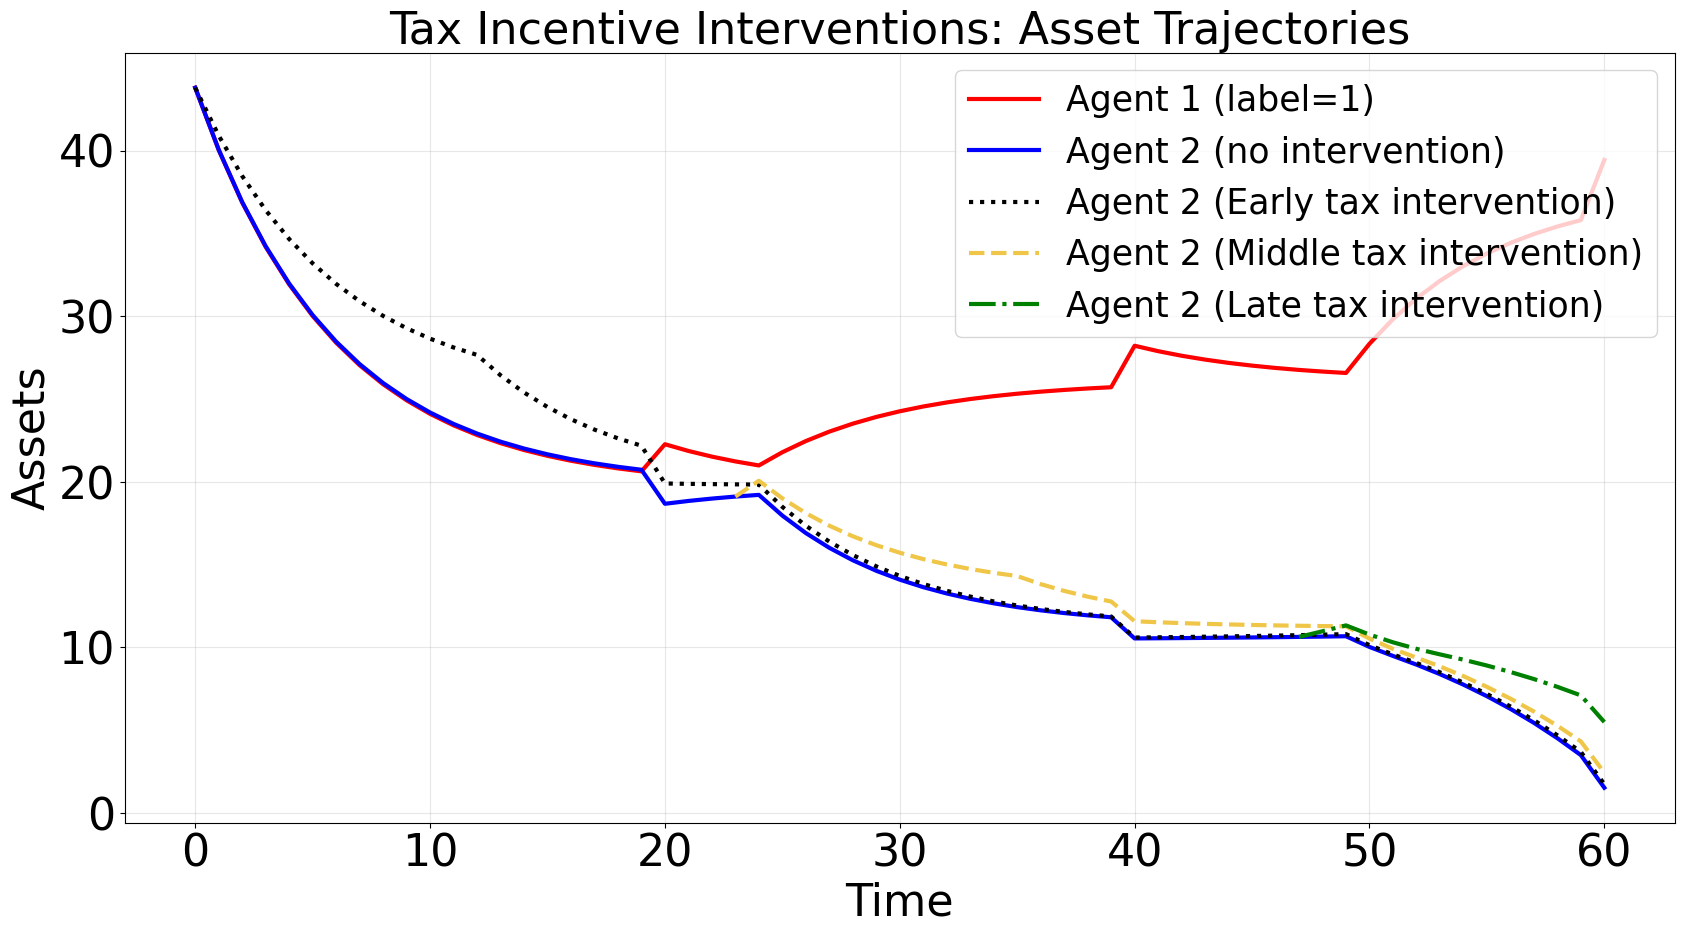

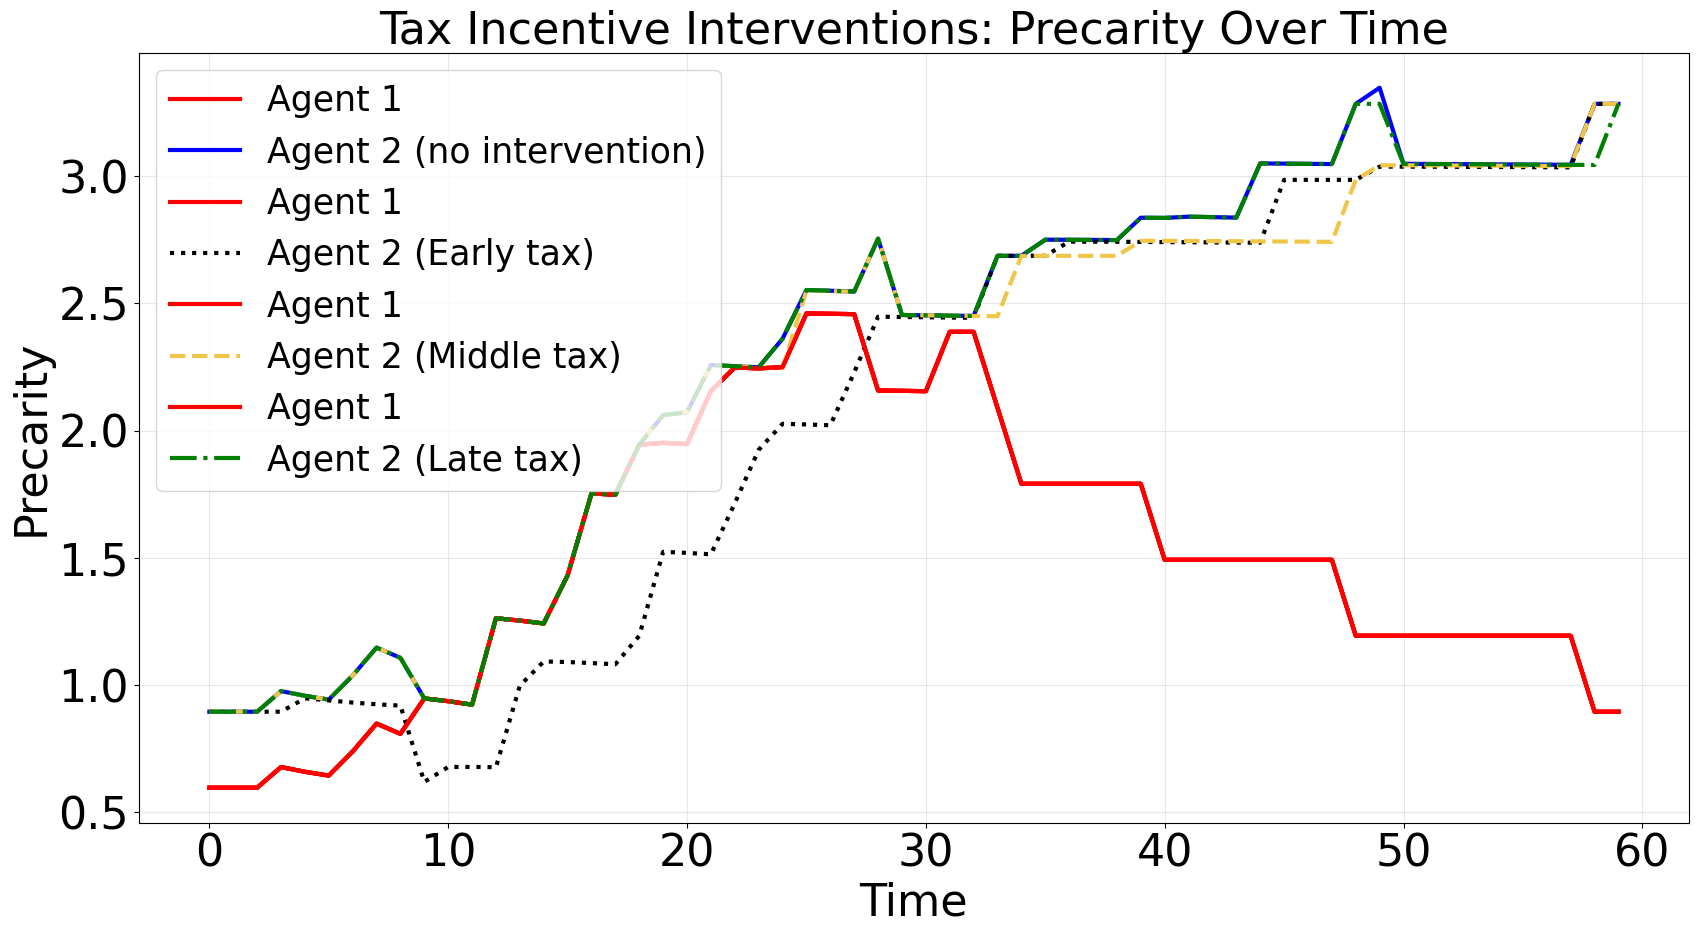

In [6]:
print("\n--- Graph 2: Tax Incentives Interventions ---")

def intervention_function(income):
    if income <= 9.700 / 12:
        return 1 / (1 - 0.1)
    elif income <= 39.475 / 12:
        return 1 / (1 - 0.12)
    elif income <= 84.200 / 12:
        return 1 / (1 - 0.22)
    elif income <= 160.725 / 12:
        return 1 / (1 - 0.24)
    elif income <= 204.100 / 12:
        return 1 / (1 - 0.32)
    elif income <= 510.300 / 12:
        return 1 / (1 - 0.35)
    else:
        return 1 / (1 - 0.37)

# Agent 1 (no intervention needed)
init_income = best_pair[1][1]
init_saving = best_pair[1][0]
init_state_1 = getState([init_saving])[0]
a_1_tax, inc_1_tax = compute_asset_series_static_clf_interventions(
    con_model, a_star, σ_star, init_state_1, clf_real,
    initincome=init_income, T=T, init_a=init_saving,
    permanenet_shock_gap=25, temporary_shock_gap=20,
    permanenet_shock=0.4, temporary_shock=0.6)
init_income1_tax = init_income

# Agent 2 — no intervention
init_income = best_pair[0][1]
init_saving = best_pair[0][0]
init_state_2 = getState([init_saving])[0]
a_2_tax, inc_2_tax = compute_asset_series_static_clf_interventions(
    con_model, a_star, σ_star, init_state_2, clf_real,
    initincome=init_income, T=T, init_a=init_saving,
    permanenet_shock_gap=25, temporary_shock_gap=20,
    permanenet_shock=0.4, temporary_shock=0.6)

# Agent 2 — early intervention (month 1-12)
a_3_tax, inc_3_tax = compute_asset_series_static_clf_interventions(
    con_model, a_star, σ_star, init_state_2, clf_real,
    initincome=init_income, T=T, init_a=init_saving,
    permanenet_shock_gap=25, temporary_shock_gap=20,
    permanenet_shock=0.4, temporary_shock=0.6,
    interventions={1: {'type': 'temporal', 'rate_function': intervention_function, 'duration': 12}})

# Agent 2 — middle intervention (month 24-36)
a_4_tax, inc_4_tax = compute_asset_series_static_clf_interventions(
    con_model, a_star, σ_star, init_state_2, clf_real,
    initincome=init_income, T=T, init_a=init_saving,
    permanenet_shock_gap=25, temporary_shock_gap=20,
    permanenet_shock=0.4, temporary_shock=0.6,
    interventions={24: {'type': 'temporal', 'rate_function': intervention_function, 'duration': 12}})

# Agent 2 — late intervention (month 48-60)
a_5_tax, inc_5_tax = compute_asset_series_static_clf_interventions(
    con_model, a_star, σ_star, init_state_2, clf_real,
    initincome=init_income, T=T, init_a=init_saving,
    permanenet_shock_gap=25, temporary_shock_gap=20,
    permanenet_shock=0.4, temporary_shock=0.6,
    interventions={48: {'type': 'temporal', 'rate_function': intervention_function, 'duration': 12}})

# Plot assets
plt.figure(3, figsize=(20, 10))
plt.plot(range(len(a_1_tax)), a_1_tax, label="Agent 1 (label=1)", linewidth=3, color='red')
plt.plot(range(len(a_2_tax)), a_2_tax, label="Agent 2 (no intervention)", linewidth=3, color='blue')
plt.plot(range(len(a_3_tax)), a_3_tax, label="Agent 2 (Early tax intervention)", linewidth=3,
         color='black', linestyle='dotted')
plt.plot(range(23, len(a_4_tax)), a_4_tax[23:], label="Agent 2 (Middle tax intervention)", linewidth=3,
         color='#f0c648', linestyle='dashed')
plt.plot(range(47, len(a_5_tax)), a_5_tax[47:], label="Agent 2 (Late tax intervention)", linewidth=3,
         color='green', linestyle='dashdot')
plt.legend(loc="upper right")
plt.ylabel('Assets')
plt.xlabel('Time')
plt.title('Tax Incentive Interventions: Asset Trajectories')
plt.grid(alpha=0.3)
plt.savefig('g2_tax_interventions_assets.png', dpi=100, bbox_inches='tight')
plt.show()

# Precarity for tax interventions
a_1_seq_tax = get_sequence(a_1_tax, assets_lvls, asset_states)
a_2_seq_tax = get_sequence(a_2_tax, assets_lvls, asset_states)
a_3_seq_tax = get_sequence(a_3_tax, assets_lvls, asset_states)
a_4_seq_tax = get_sequence(a_4_tax, assets_lvls, asset_states)
a_5_seq_tax = get_sequence(a_5_tax, assets_lvls, asset_states)

prec_1_tax = []
for i in range(1, len(a_1_tax)):
    w = generateWeight(a_1_seq_tax[:i + 1], assets_lvls, asset_states)
    prec_1_tax.append(precarityQuantification(
        a_1_seq_tax[:i + 1], asset_states, w, 0.2, 1, 1.2,
        init_prec_state_1, windowSize=ws, useInit=True,
        useIncome=True, income=init_income1_tax))

for seq, label, color, ls, marker_start in [
    (a_2_seq_tax, "Agent 2 (no intervention)", 'blue', 'solid', 0),
    (a_3_seq_tax, "Agent 2 (Early tax)", 'black', 'dotted', 0),
    (a_4_seq_tax, "Agent 2 (Middle tax)", '#f0c648', 'dashed', 23),
    (a_5_seq_tax, "Agent 2 (Late tax)", 'green', 'dashdot', 47),
]:
    prec = []
    for i in range(1, len(seq)):
        w = generateWeight(seq[:i + 1], assets_lvls, asset_states)
        prec.append(precarityQuantification(
            seq[:i + 1], asset_states, w, 0.2, 1, 1.2,
            init_prec_state_2, windowSize=ws, useInit=True,
            useIncome=True, income=init_income))

    offset = marker_start if marker_start > 0 else 0
    if offset > len(prec):
        offset = 0
    plt.figure(4, figsize=(20, 10))
    plt.plot(range(len(prec_1_tax)), prec_1_tax, label="Agent 1", linewidth=3, color='red')
    plt.plot(range(len(prec)), prec, label=label, linewidth=3, color=color, linestyle=ls)

plt.legend(loc="upper left")
plt.ylabel('Precarity')
plt.xlabel('Time')
plt.title('Tax Incentive Interventions: Precarity Over Time')
plt.grid(alpha=0.3)
plt.savefig('g2_tax_interventions_precarity.png', dpi=100, bbox_inches='tight')
plt.show()


## Graph 3: GRAPH 3: INTERVENTIONS — DIRECT SUBSIDIES



--- Graph 3: Direct Subsidies Interventions ---


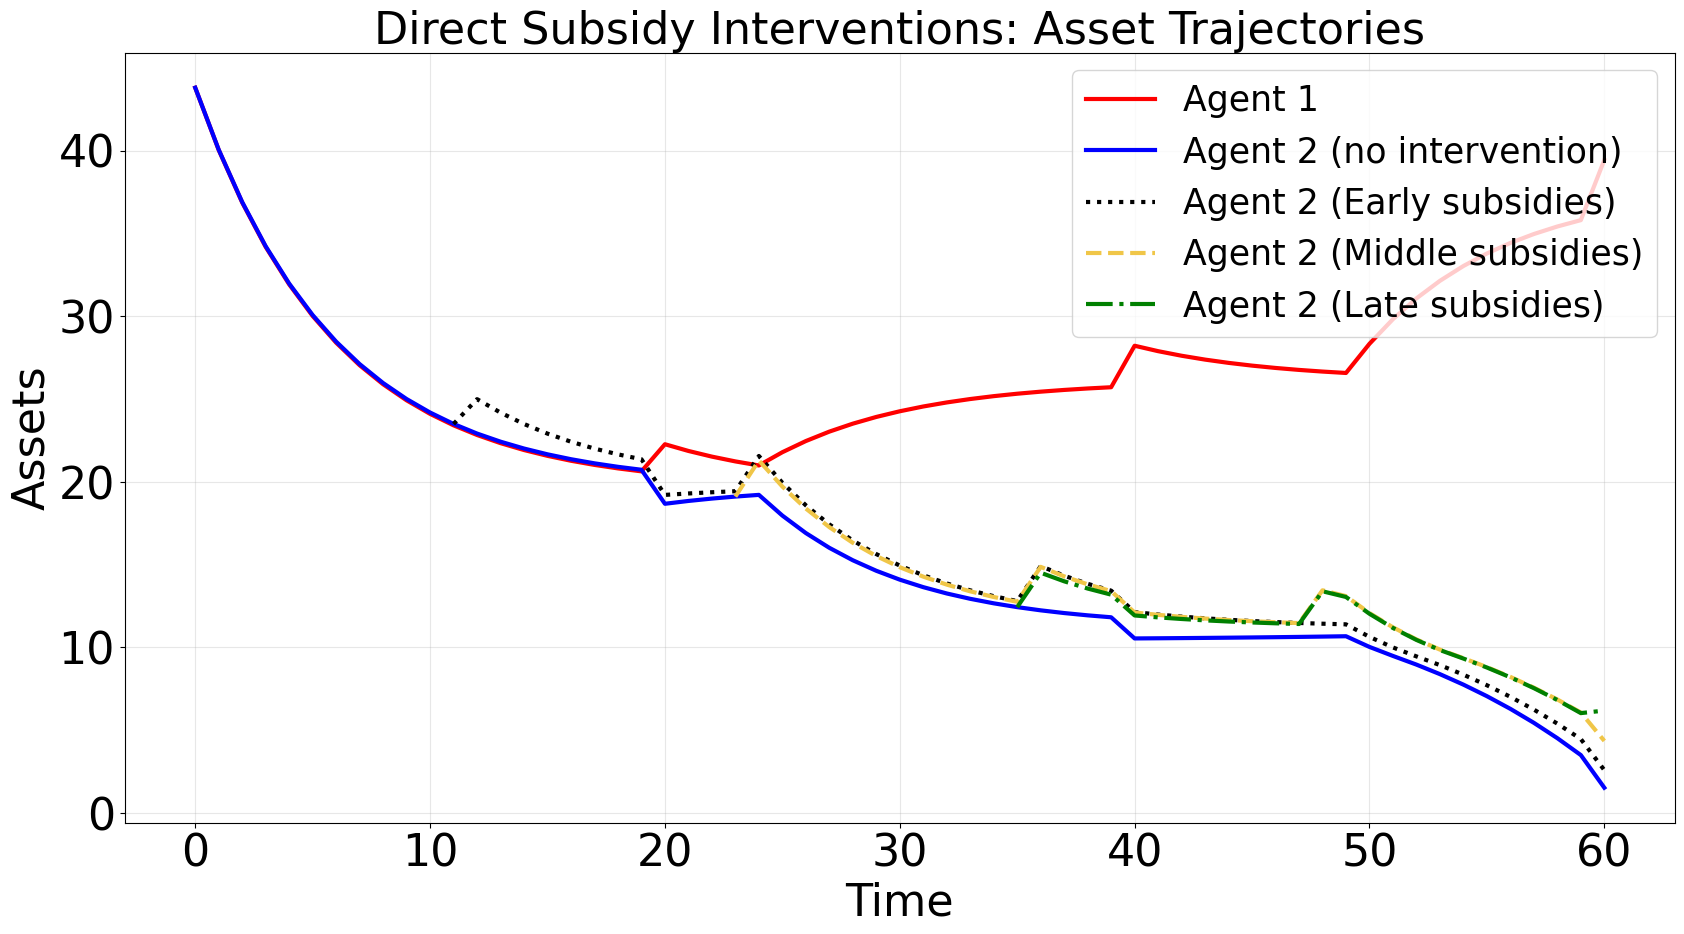

In [7]:
print("\n--- Graph 3: Direct Subsidies Interventions ---")

# Agent 2 — no intervention (reuse a_2)
# Agent 2 — early subsidies (months 12, 24, 36)
a_3_sub, _ = compute_asset_series_static_clf_interventions(
    con_model, a_star, σ_star, init_state_2, clf_real,
    initincome=init_income, T=T, init_a=init_saving,
    permanenet_shock_gap=25, temporary_shock_gap=20,
    permanenet_shock=0.4, temporary_shock=0.6,
    interventions={12: {'type': 'one_shot', 'value': 3},
                   24: {'type': 'one_shot', 'value': 3},
                   36: {'type': 'one_shot', 'value': 3}})

# Agent 2 — middle subsidies (months 24, 36, 48)
a_4_sub, _ = compute_asset_series_static_clf_interventions(
    con_model, a_star, σ_star, init_state_2, clf_real,
    initincome=init_income, T=T, init_a=init_saving,
    permanenet_shock_gap=25, temporary_shock_gap=20,
    permanenet_shock=0.4, temporary_shock=0.6,
    interventions={24: {'type': 'one_shot', 'value': 3},
                   36: {'type': 'one_shot', 'value': 3},
                   48: {'type': 'one_shot', 'value': 3}})

# Agent 2 — late subsidies (months 36, 48, 60)
a_5_sub, _ = compute_asset_series_static_clf_interventions(
    con_model, a_star, σ_star, init_state_2, clf_real,
    initincome=init_income, T=T, init_a=init_saving,
    permanenet_shock_gap=25, temporary_shock_gap=20,
    permanenet_shock=0.4, temporary_shock=0.6,
    interventions={36: {'type': 'one_shot', 'value': 3},
                   48: {'type': 'one_shot', 'value': 3},
                   60: {'type': 'one_shot', 'value': 3}})

plt.figure(5, figsize=(20, 10))
plt.plot(range(len(a_1)), a_1, label="Agent 1", linewidth=3, color='red')
plt.plot(range(len(a_2)), a_2, label="Agent 2 (no intervention)", linewidth=3, color='blue')
plt.plot(range(11, len(a_3_sub)), a_3_sub[11:], label="Agent 2 (Early subsidies)", linewidth=3,
         color='black', linestyle='dotted')
plt.plot(range(23, len(a_4_sub)), a_4_sub[23:], label="Agent 2 (Middle subsidies)", linewidth=3,
         color='#f0c648', linestyle='dashed')
plt.plot(range(35, len(a_5_sub)), a_5_sub[35:], label="Agent 2 (Late subsidies)", linewidth=3,
         color='green', linestyle='dashdot')
plt.legend(loc="upper right")
plt.ylabel('Assets')
plt.xlabel('Time')
plt.title('Direct Subsidy Interventions: Asset Trajectories')
plt.grid(alpha=0.3)
plt.savefig('g3_subsidy_interventions_assets.png', dpi=100, bbox_inches='tight')
plt.show()


## Graph 4: GRAPH 4: GIG WORKER vs OFFICE WORKER



--- Graph 4: Gig Worker vs Office Worker ---


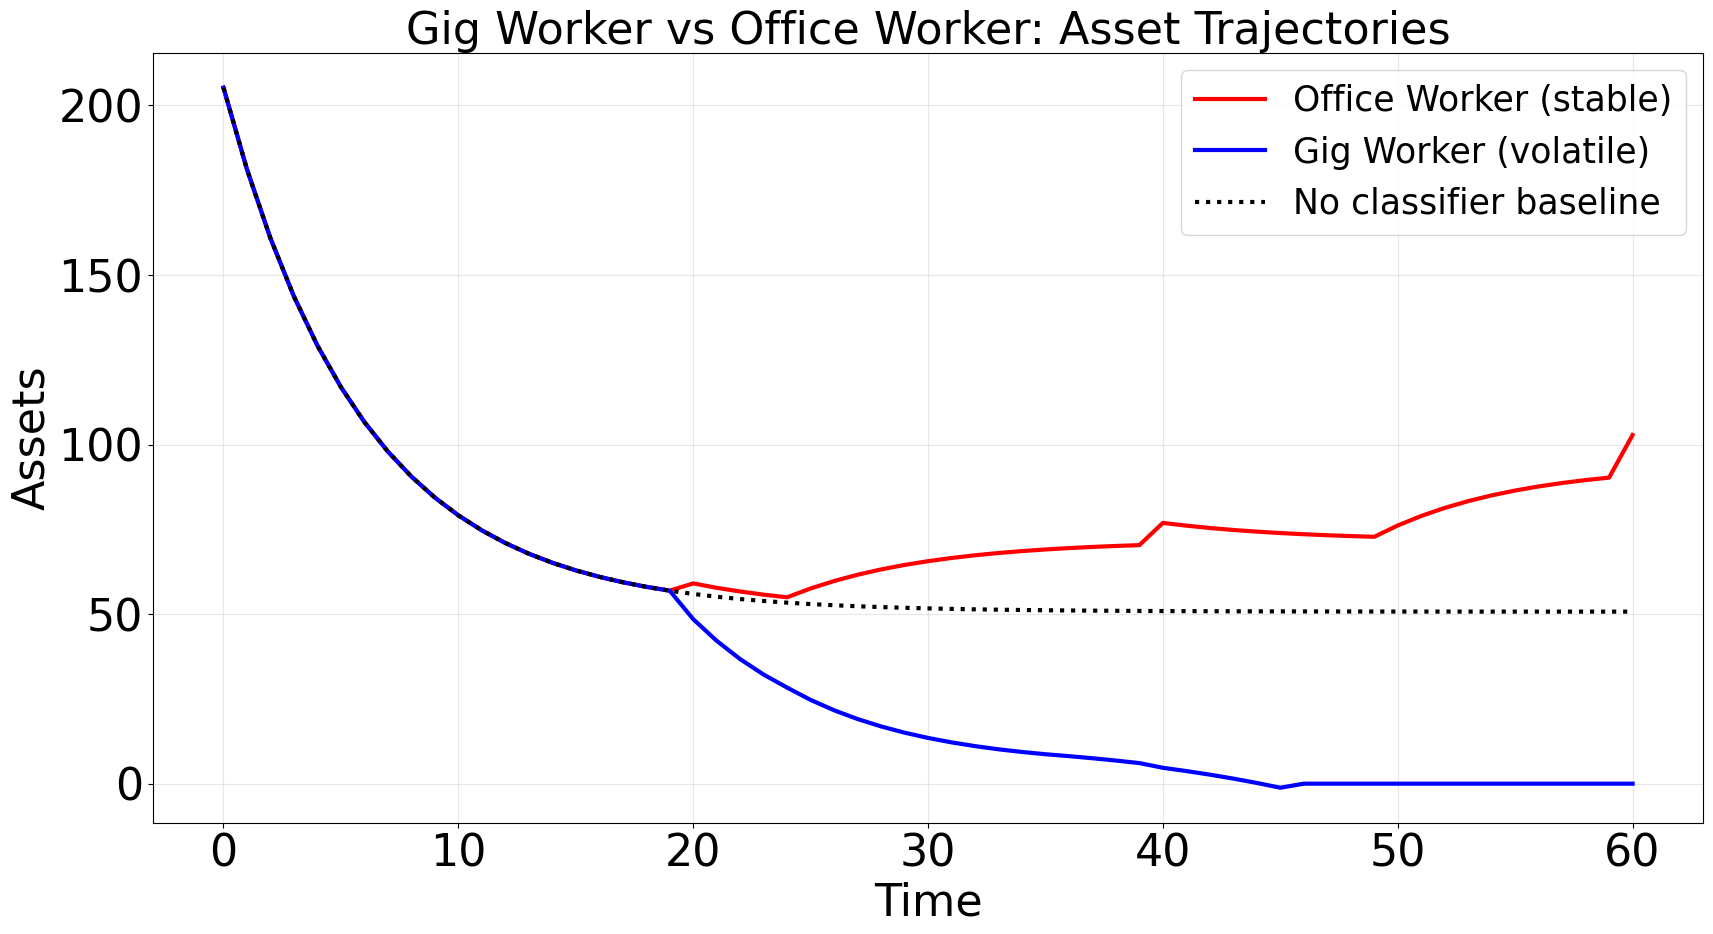

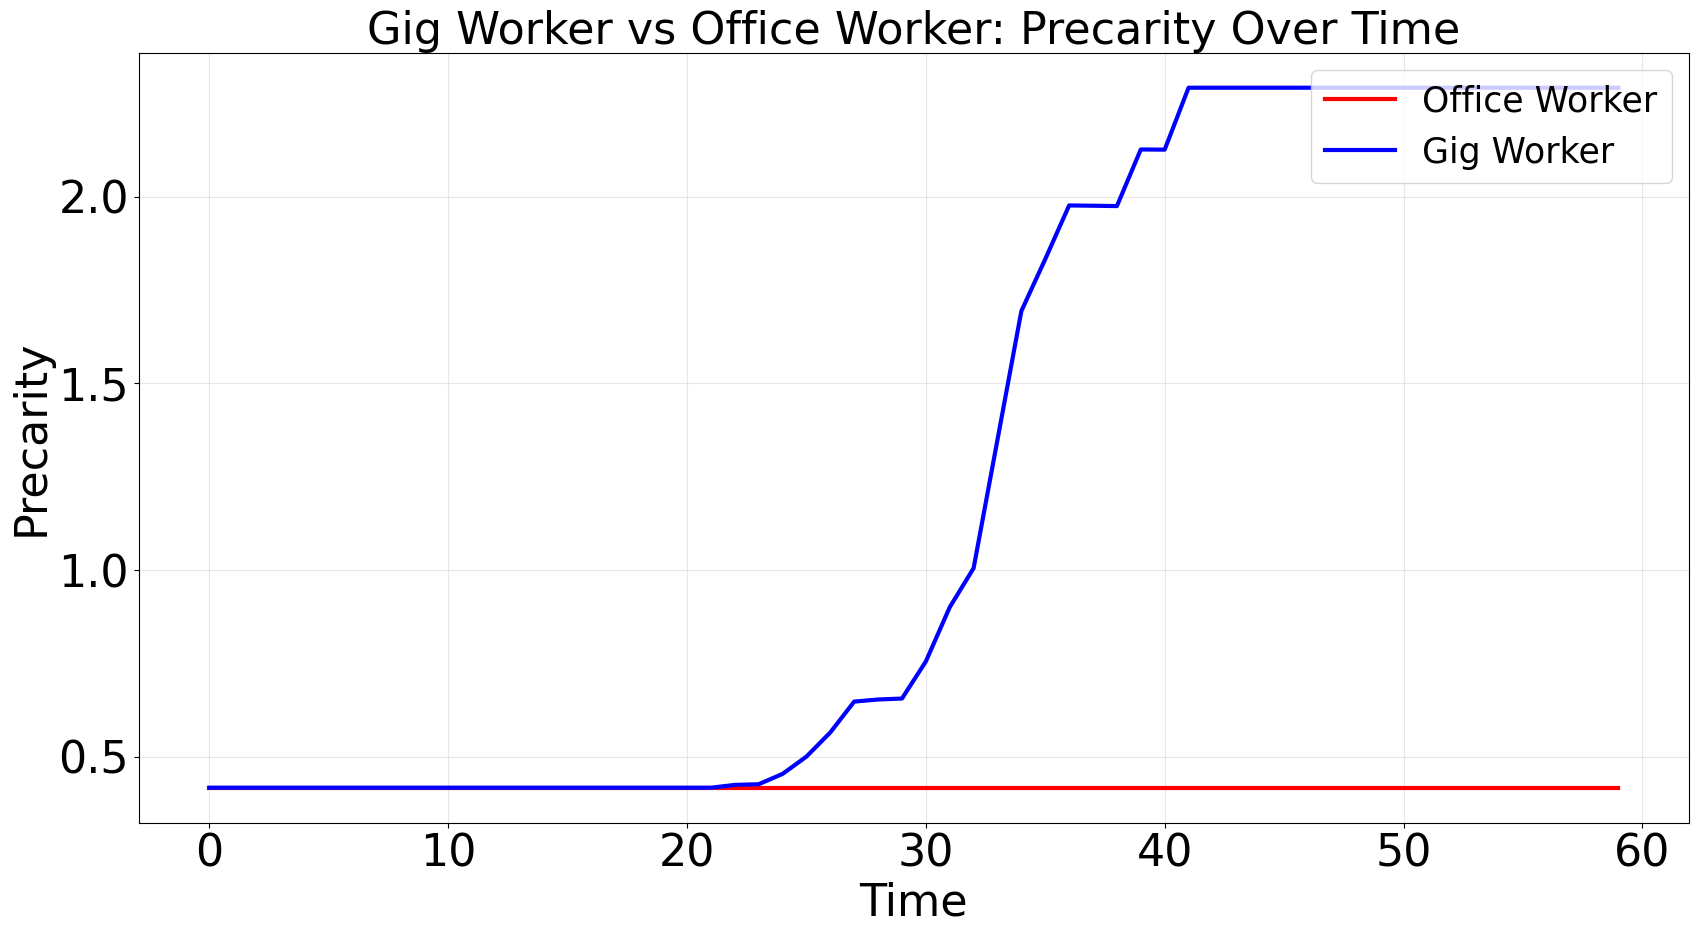

In [8]:
print("\n--- Graph 4: Gig Worker vs Office Worker ---")

def compute_asset_series_income_distribution(con_model, a_star, σ_star,
                                             initincome=0, T=500_000, init_a=0,
                                             income_distribution=None,
                                             clf_info=None,
                                             interventions=None):
    if income_distribution is None:
        income_distribution = {}
    if clf_info is None:
        clf_info = {'function': None, 'perm_gap': 100, 'perm_shock': 0,
                    'temp_gap': 100, 'temp_shock': 0}
    if interventions is None:
        interventions = {}

    one_shot_interventions = {}
    temporal_interventions = {}
    for key in interventions:
        if interventions[key]['type'] == 'one_shot':
            one_shot_interventions[key] = interventions[key]['value']
        else:
            dur = interventions[key]['duration']
            for i in range(dur):
                temporal_interventions[key + i] = interventions[key]['rate_function']

    σ_func = lambda a, z: interp(a_star[:, z], σ_star[:, z], a)
    a = np.zeros(T + 1)
    a[0] = init_a
    y_val = [initincome]
    current_income = initincome
    for t in range(T):
        if (t + 1) in income_distribution:
            current_income = income_distribution[t + 1]

        y_tmp = current_income
        if clf_info['function'] is not None:
            label = clf_info['function'].predict(np.array([[a[t], current_income]]))[0]
            if ((t + 1) % clf_info['perm_gap'] == 0) and label == 0:
                current_income *= (1 - clf_info['perm_shock'])
                y_tmp = current_income
            elif ((t + 1) % clf_info['perm_gap'] == 0) and label == 1:
                current_income *= (1 + clf_info['perm_shock'])
                y_tmp = current_income
            if ((t + 1) % clf_info['temp_gap'] == 0) and label == 0:
                current_income *= (1 - clf_info['temp_shock'])
            elif ((t + 1) % clf_info['temp_gap'] == 0) and label == 1:
                current_income *= (1 + clf_info['temp_shock'])

        if (t + 1) in one_shot_interventions:
            current_income += one_shot_interventions[t + 1]
        if (t + 1) in temporal_interventions:
            current_income *= temporal_interventions[t + 1](current_income)

        R = con_model.R()
        z = getIncomeState(current_income)
        s = a[t] - max(σ_func(a[t], z), basic_expenditure(current_income))
        a[t + 1] = R * s + current_income
        y_val.append(current_income)
        current_income = y_tmp
        if a[t + 1] <= 0:
            break
    return a, y_val


def generateIncomeDistributionList(time_slots, low_incomes):
    incomes_dict = {}
    for t in time_slots:
        incomes_dict[t] = np.random.choice(low_incomes)
    return incomes_dict


inc_30_val = np.percentile(incomes, 30)
inc_80_val = np.percentile(incomes, 80)
low_incomes = np.array([i for i in incomes if i <= inc_30_val])
high_incomes = np.array([i for i in incomes if i >= inc_80_val])

np.random.seed(29)

# Office worker (stable income) vs Gig worker (volatile income)
init_income_gig = np.random.choice(incomes)
init_saving_g = get_savings(init_income_gig)

# Office worker: no income distribution changes, with classifier
income_dist_office = generateIncomeDistributionList([], low_incomes)
clf_info = {'function': clf_real, 'perm_gap': 25, 'perm_shock': 0.4,
            'temp_gap': 20, 'temp_shock': 0.6}

a_office, inc_office = compute_asset_series_income_distribution(
    con_model, a_star, σ_star, initincome=init_income_gig, T=T,
    init_a=init_saving_g, income_distribution=income_dist_office,
    clf_info=clf_info)

# Gig worker: income drops at month 20
income_dist_gig = generateIncomeDistributionList([20], low_incomes)
a_gig, inc_gig = compute_asset_series_income_distribution(
    con_model, a_star, σ_star, initincome=init_income_gig, T=T,
    init_a=init_saving_g, income_distribution=income_dist_gig,
    clf_info=clf_info)

# No classifier baseline
a_base, inc_base = compute_asset_series_income_distribution(
    con_model, a_star, σ_star, initincome=init_income_gig, T=T,
    init_a=init_saving_g, income_distribution=income_dist_office)

plt.figure(6, figsize=(20, 10))
plt.plot(range(len(a_office)), a_office, label="Office Worker (stable)", linewidth=3, color='red')
plt.plot(range(len(a_gig)), a_gig, label="Gig Worker (volatile)", linewidth=3, color='blue')
plt.plot(range(len(a_base)), a_base, label="No classifier baseline", linewidth=3, color='black', linestyle='dotted')
plt.legend(loc="upper right")
plt.ylabel('Assets')
plt.xlabel('Time')
plt.title('Gig Worker vs Office Worker: Asset Trajectories')
plt.grid(alpha=0.3)
plt.savefig('g4_gig_vs_office_assets.png', dpi=100, bbox_inches='tight')
plt.show()

# Precarity for gig vs office
a_office_seq = get_sequence(a_office, assets_lvls, asset_states)
a_gig_seq = get_sequence(a_gig, assets_lvls, asset_states)

init_prec_state_g = min(np.array(get_sequence(np.array([init_saving_g]), assets_lvls, asset_states))[0] + 1, asset_states[-1])

prec_office = []
for i in range(1, len(a_office)):
    w = generateWeight(a_office_seq[:i + 1], assets_lvls, asset_states)
    prec_office.append(precarityQuantification(
        a_office_seq[:i + 1], asset_states, w, 0.2, 1, 1.2,
        init_prec_state_g, windowSize=ws, useInit=True,
        useIncome=True, income=init_income_gig))

prec_gig = []
for i in range(1, len(a_gig)):
    w = generateWeight(a_gig_seq[:i + 1], assets_lvls, asset_states)
    prec_gig.append(precarityQuantification(
        a_gig_seq[:i + 1], asset_states, w, 0.2, 1, 1.2,
        init_prec_state_g, windowSize=ws, useInit=True,
        useIncome=True, income=init_income_gig))

plt.figure(7, figsize=(20, 10))
plt.plot(range(len(prec_office)), prec_office, label="Office Worker", linewidth=3, color='red')
plt.plot(range(len(prec_gig)), prec_gig, label="Gig Worker", linewidth=3, color='blue')
plt.legend(loc="upper right")
plt.ylabel('Precarity')
plt.xlabel('Time')
plt.title('Gig Worker vs Office Worker: Precarity Over Time')
plt.grid(alpha=0.3)
plt.savefig('g4_gig_vs_office_precarity.png', dpi=100, bbox_inches='tight')
plt.show()


## Graph 5: GRAPH 5: GIG WORKER SCENARIO — TAX INCENTIVES



--- Graph 5: Gig Worker Scenario — Tax Incentives ---


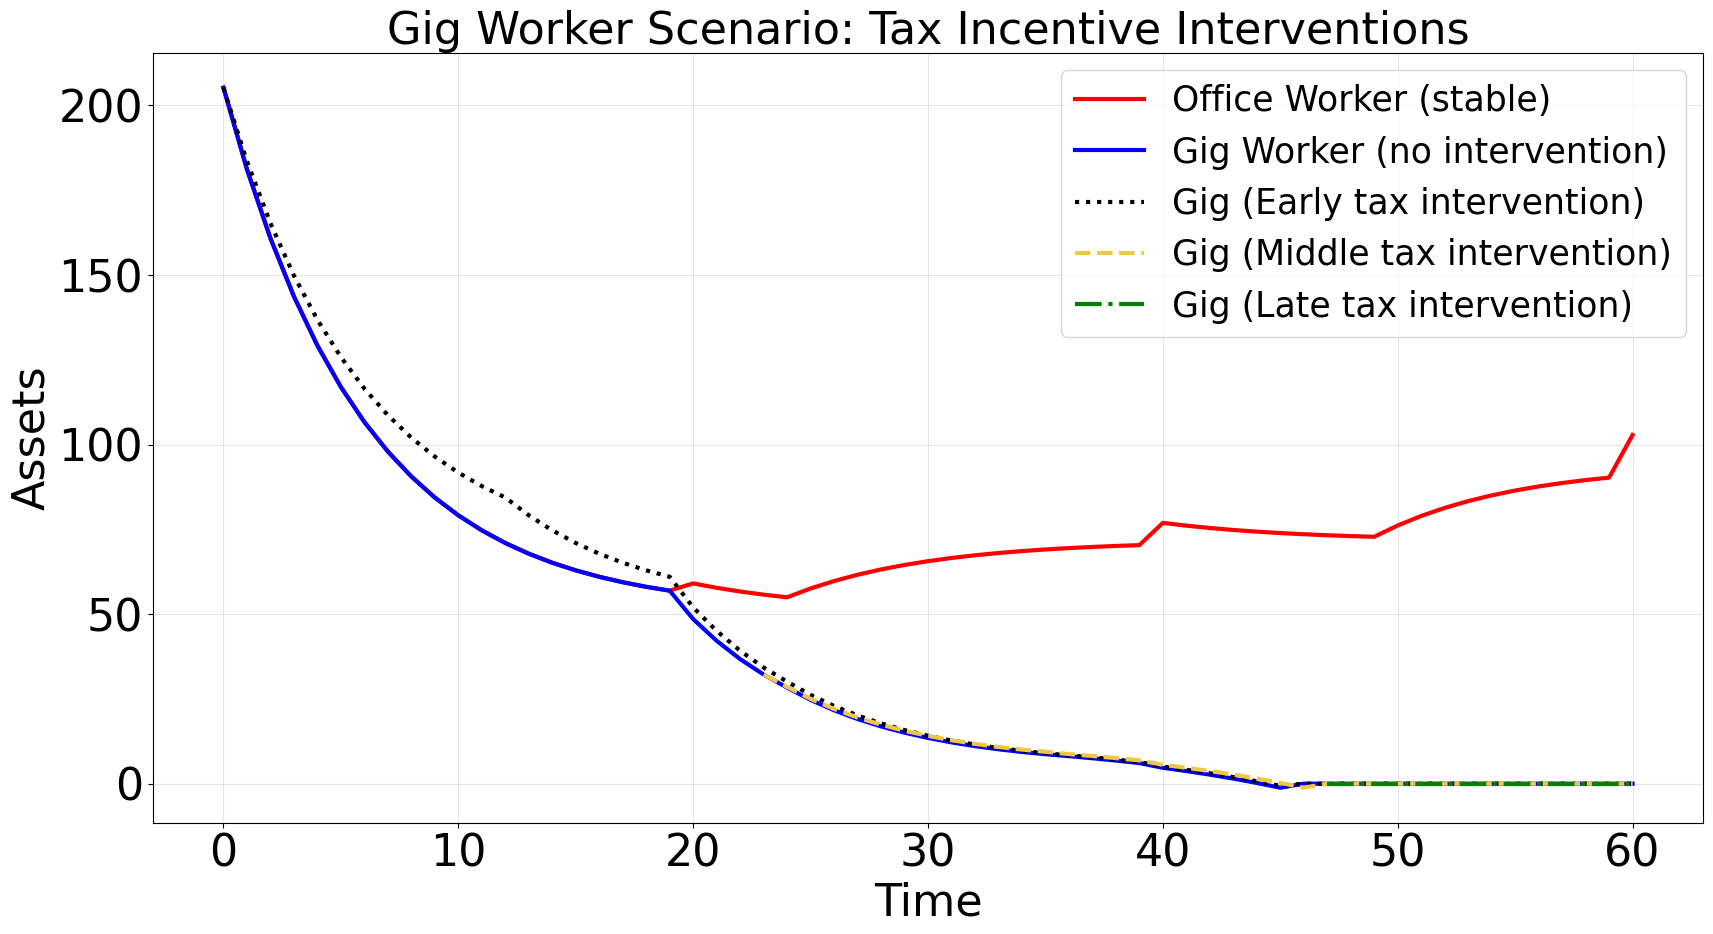

In [9]:
print("\n--- Graph 5: Gig Worker Scenario — Tax Incentives ---")

# Gig worker with tax interventions
interventions_tax_early = {1: {'type': 'temporal', 'rate_function': intervention_function, 'duration': 12}}
interventions_tax_mid = {24: {'type': 'temporal', 'rate_function': intervention_function, 'duration': 12}}
interventions_tax_late = {48: {'type': 'temporal', 'rate_function': intervention_function, 'duration': 12}}

a_gig_tax_early, _ = compute_asset_series_income_distribution(
    con_model, a_star, σ_star, initincome=init_income_gig, T=T,
    init_a=init_saving_g, income_distribution=income_dist_gig,
    clf_info=clf_info, interventions=interventions_tax_early)

a_gig_tax_mid, _ = compute_asset_series_income_distribution(
    con_model, a_star, σ_star, initincome=init_income_gig, T=T,
    init_a=init_saving_g, income_distribution=income_dist_gig,
    clf_info=clf_info, interventions=interventions_tax_mid)

a_gig_tax_late, _ = compute_asset_series_income_distribution(
    con_model, a_star, σ_star, initincome=init_income_gig, T=T,
    init_a=init_saving_g, income_distribution=income_dist_gig,
    clf_info=clf_info, interventions=interventions_tax_late)

plt.figure(8, figsize=(20, 10))
plt.plot(range(len(a_office)), a_office, label="Office Worker (stable)", linewidth=3, color='red')
plt.plot(range(len(a_gig)), a_gig, label="Gig Worker (no intervention)", linewidth=3, color='blue')
plt.plot(range(len(a_gig_tax_early)), a_gig_tax_early, label="Gig (Early tax intervention)", linewidth=3,
         color='black', linestyle='dotted')
plt.plot(range(23, len(a_gig_tax_mid)), a_gig_tax_mid[23:], label="Gig (Middle tax intervention)", linewidth=3,
         color='#f0c648', linestyle='dashed')
plt.plot(range(47, len(a_gig_tax_late)), a_gig_tax_late[47:], label="Gig (Late tax intervention)", linewidth=3,
         color='green', linestyle='dashdot')
plt.legend(loc="upper right")
plt.ylabel('Assets')
plt.xlabel('Time')
plt.title('Gig Worker Scenario: Tax Incentive Interventions')
plt.grid(alpha=0.3)
plt.savefig('g5_gig_tax_interventions.png', dpi=100, bbox_inches='tight')
plt.show()


## Graph 6: GRAPH 6: GIG WORKER SCENARIO — DIRECT SUBSIDIES



--- Graph 6: Gig Worker Scenario — Direct Subsidies ---


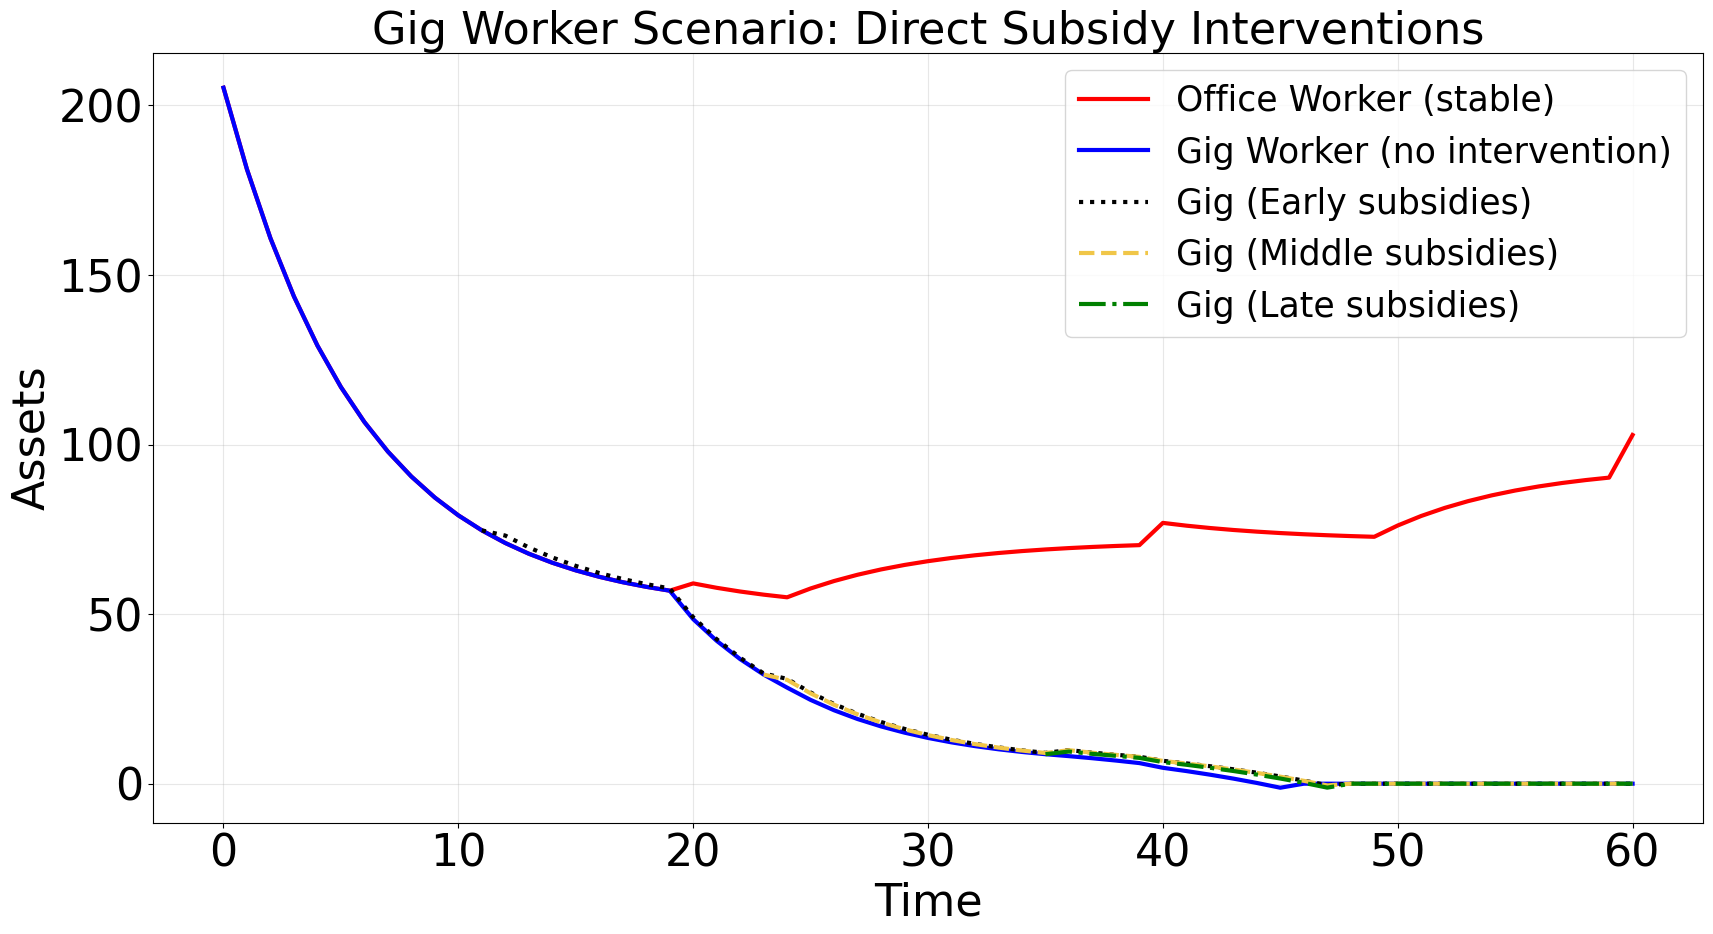


=== ALL GRAPHS COMPLETE ===
Files saved: g1_*.png, g2_*.png, g3_*.png, g4_*.png, g5_*.png, g6_*.png


In [10]:
print("\n--- Graph 6: Gig Worker Scenario — Direct Subsidies ---")

sub_early = {12: {'type': 'one_shot', 'value': 3},
             24: {'type': 'one_shot', 'value': 3},
             36: {'type': 'one_shot', 'value': 3}}
sub_mid = {24: {'type': 'one_shot', 'value': 3},
           36: {'type': 'one_shot', 'value': 3},
           48: {'type': 'one_shot', 'value': 3}}
sub_late = {36: {'type': 'one_shot', 'value': 3},
            48: {'type': 'one_shot', 'value': 3},
            60: {'type': 'one_shot', 'value': 3}}

a_gig_sub_early, _ = compute_asset_series_income_distribution(
    con_model, a_star, σ_star, initincome=init_income_gig, T=T,
    init_a=init_saving_g, income_distribution=income_dist_gig,
    clf_info=clf_info, interventions=sub_early)

a_gig_sub_mid, _ = compute_asset_series_income_distribution(
    con_model, a_star, σ_star, initincome=init_income_gig, T=T,
    init_a=init_saving_g, income_distribution=income_dist_gig,
    clf_info=clf_info, interventions=sub_mid)

a_gig_sub_late, _ = compute_asset_series_income_distribution(
    con_model, a_star, σ_star, initincome=init_income_gig, T=T,
    init_a=init_saving_g, income_distribution=income_dist_gig,
    clf_info=clf_info, interventions=sub_late)

plt.figure(9, figsize=(20, 10))
plt.plot(range(len(a_office)), a_office, label="Office Worker (stable)", linewidth=3, color='red')
plt.plot(range(len(a_gig)), a_gig, label="Gig Worker (no intervention)", linewidth=3, color='blue')
plt.plot(range(11, len(a_gig_sub_early)), a_gig_sub_early[11:], label="Gig (Early subsidies)", linewidth=3,
         color='black', linestyle='dotted')
plt.plot(range(23, len(a_gig_sub_mid)), a_gig_sub_mid[23:], label="Gig (Middle subsidies)", linewidth=3,
         color='#f0c648', linestyle='dashed')
plt.plot(range(35, len(a_gig_sub_late)), a_gig_sub_late[35:], label="Gig (Late subsidies)", linewidth=3,
         color='green', linestyle='dashdot')
plt.legend(loc="upper right")
plt.ylabel('Assets')
plt.xlabel('Time')
plt.title('Gig Worker Scenario: Direct Subsidy Interventions')
plt.grid(alpha=0.3)
plt.savefig('g6_gig_subsidy_interventions.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n=== ALL GRAPHS COMPLETE ===")
print("Files saved: g1_*.png, g2_*.png, g3_*.png, g4_*.png, g5_*.png, g6_*.png")


## Ket thuc


In [11]:
print("\n=== ALL GRAPHS COMPLETE ===")



=== ALL GRAPHS COMPLETE ===
